# Previsão de Preço de Diamantes

In [1]:
!pip install tensorflow pandas seaborn scikit-learn joblib numpy matplotlib -q


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import joblib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Carregamento e Exploração dos Dados

In [3]:
try:
    df = pd.read_csv('diamonds.csv')
except:
    df = sns.load_dataset('diamonds')

df.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [4]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [6]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

## 2. Análise Exploratória

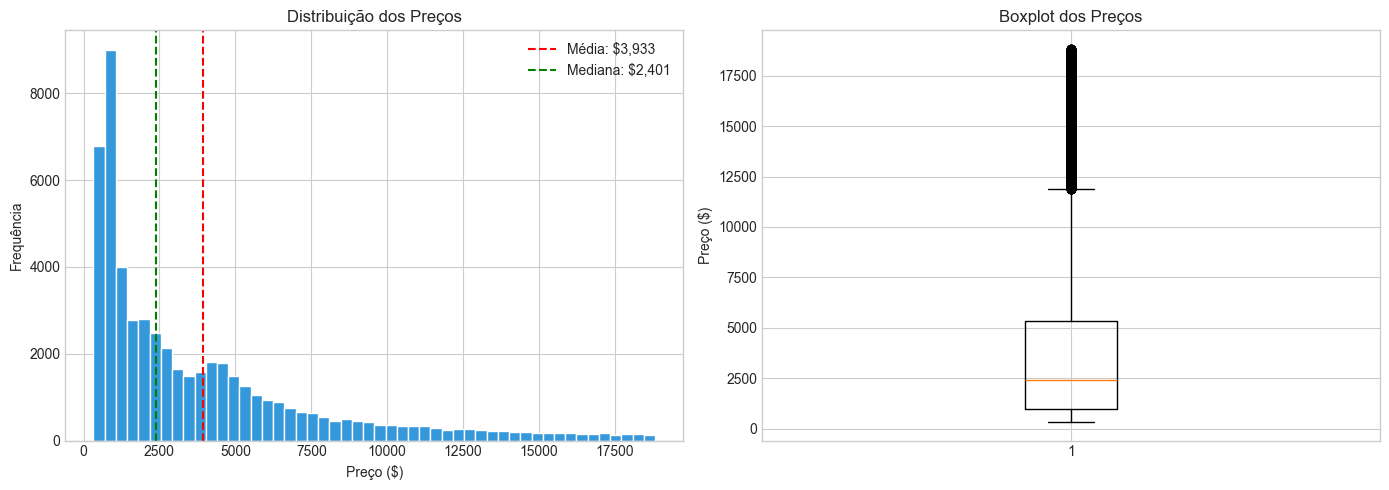

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Preço ($)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição dos Preços')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f"Média: ${df['price'].mean():,.0f}")
axes[0].axvline(df['price'].median(), color='green', linestyle='--', label=f"Mediana: ${df['price'].median():,.0f}")
axes[0].legend()

axes[1].boxplot(df['price'], vert=True)
axes[1].set_ylabel('Preço ($)')
axes[1].set_title('Boxplot dos Preços')

plt.tight_layout()
plt.show()

### Matriz de Correlação

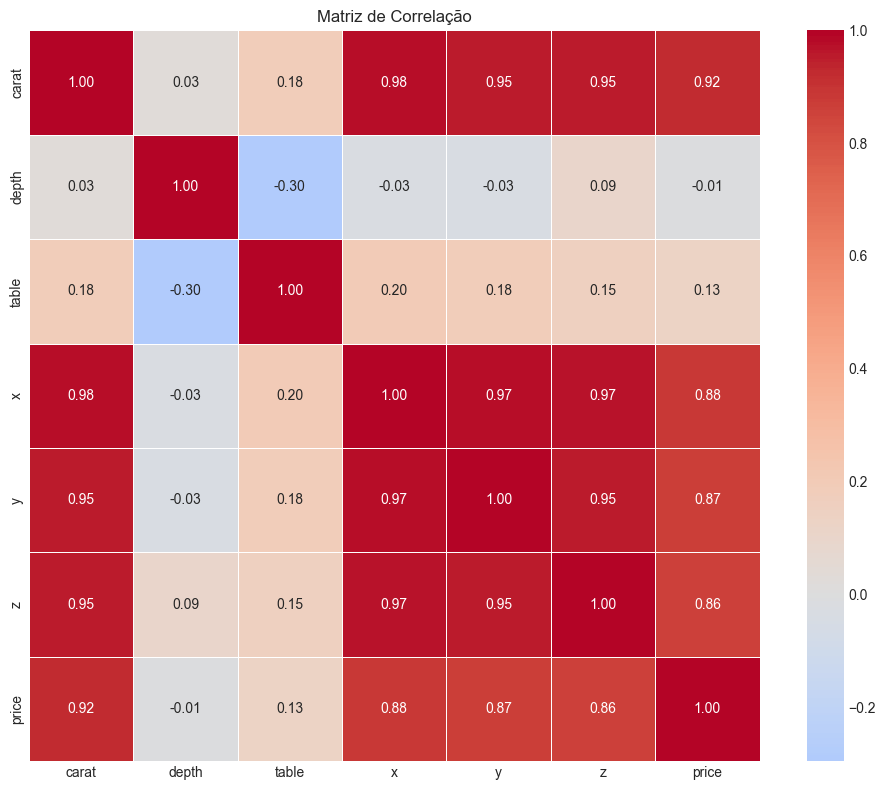

In [8]:
numerical_cols_corr = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
correlation_matrix = df[numerical_cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

### Carat vs Preço

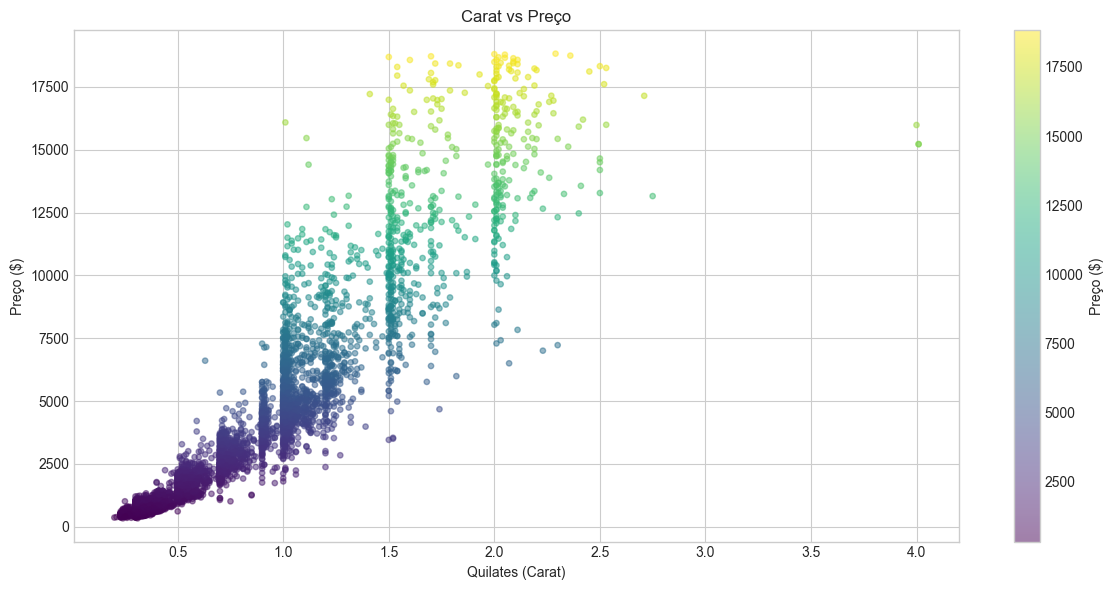

In [9]:
plt.figure(figsize=(12, 6))
sample = df.sample(5000, random_state=42)
scatter = plt.scatter(sample['carat'], sample['price'], alpha=0.5, c=sample['price'], cmap='viridis', s=15)
plt.colorbar(scatter, label='Preço ($)')
plt.xlabel('Quilates (Carat)')
plt.ylabel('Preço ($)')
plt.title('Carat vs Preço')
plt.tight_layout()
plt.show()

## 3. Pré-processamento

In [10]:
y = df['price']
X = df.drop('price', axis=1)

categorical_cols = ['cut', 'color', 'clarity']
numerical_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

input_shape = X_train_processed.shape[1]

## 4. Treinamento dos Modelos

In [11]:
def create_model_1(input_shape):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mae', metrics=['mae'])
    return model

def create_model_2(input_shape):
    model = keras.Sequential([
        keras.Input(shape=(input_shape,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mae', metrics=['mae'])
    return model

In [12]:
model1 = create_model_1(input_shape)
history1 = model1.fit(X_train_processed, y_train, validation_split=0.2, batch_size=32, epochs=50, verbose=1)

model2 = create_model_2(input_shape)
history2 = model2.fit(X_train_processed, y_train, validation_split=0.2, batch_size=32, epochs=50, verbose=1)

Epoch 1/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1914.8790 - mae: 1914.8790 - val_loss: 730.9612 - val_mae: 730.9612
Epoch 2/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 640.5726 - mae: 640.5726 - val_loss: 574.5225 - val_mae: 574.5225
Epoch 3/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 547.3525 - mae: 547.3525 - val_loss: 512.0700 - val_mae: 512.0700
Epoch 4/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 497.0067 - mae: 497.0067 - val_loss: 467.4821 - val_mae: 467.4821
Epoch 5/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 459.1550 - mae: 459.1550 - val_loss: 431.8091 - val_mae: 431.8091
Epoch 6/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 426.6517 - mae: 426.6517 - val_loss: 403.1671 - val_mae: 403.1671
Epoch 7/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 400.5213 - mae: 400.5213 - val_loss: 381.2716 - val_mae: 381.2716
Epoch 8/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 382.3383 - mae: 382.3383 - val_loss: 367

### Histórico de Treinamento

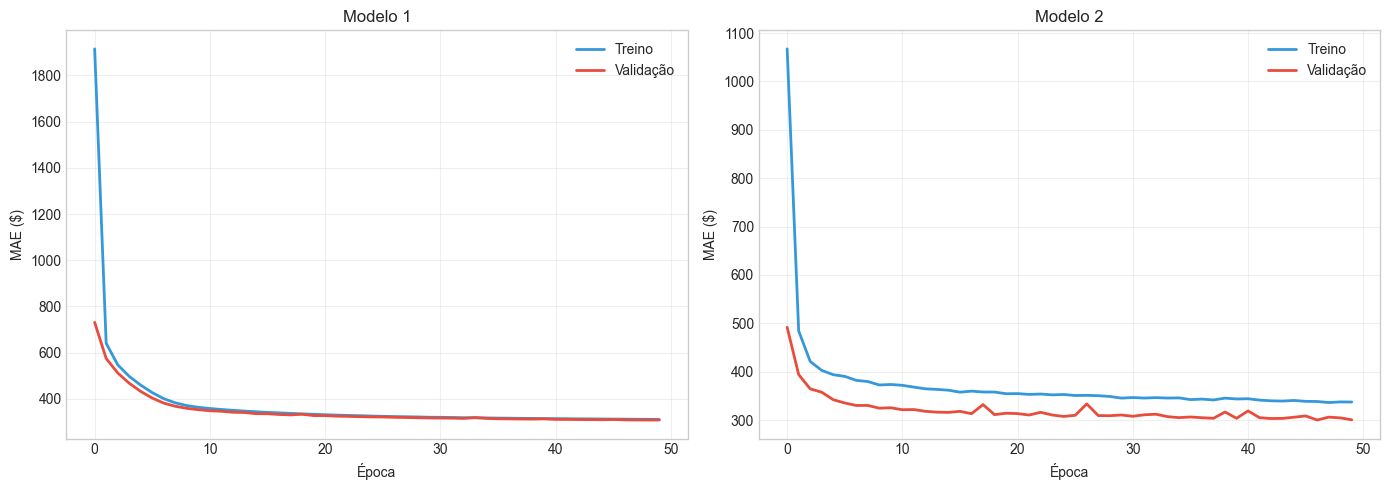

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['mae'], label='Treino', color='#3498db', linewidth=2)
axes[0].plot(history1.history['val_mae'], label='Validação', color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MAE ($)')
axes[0].set_title('Modelo 1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history2.history['mae'], label='Treino', color='#3498db', linewidth=2)
axes[1].plot(history2.history['val_mae'], label='Validação', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE ($)')
axes[1].set_title('Modelo 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Avaliação

In [14]:
loss1, mae1 = model1.evaluate(X_test_processed, y_test, verbose=0)
loss2, mae2 = model2.evaluate(X_test_processed, y_test, verbose=0)

pred1 = model1.predict(X_test_processed, verbose=0).flatten()
pred2 = model2.predict(X_test_processed, verbose=0).flatten()
pred_voting = (pred1 + pred2) / 2

mae_voting = np.mean(np.abs(y_test - pred_voting))

results = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2', 'Voting Ensemble'],
    'MAE ($)': [mae1, mae2, mae_voting]
})
results

,Modelo,MAE ($)
0,Modelo 1,305.991272
1,Modelo 2,298.888245
2,Voting Ensemble,300.095156


### Previsão vs Real

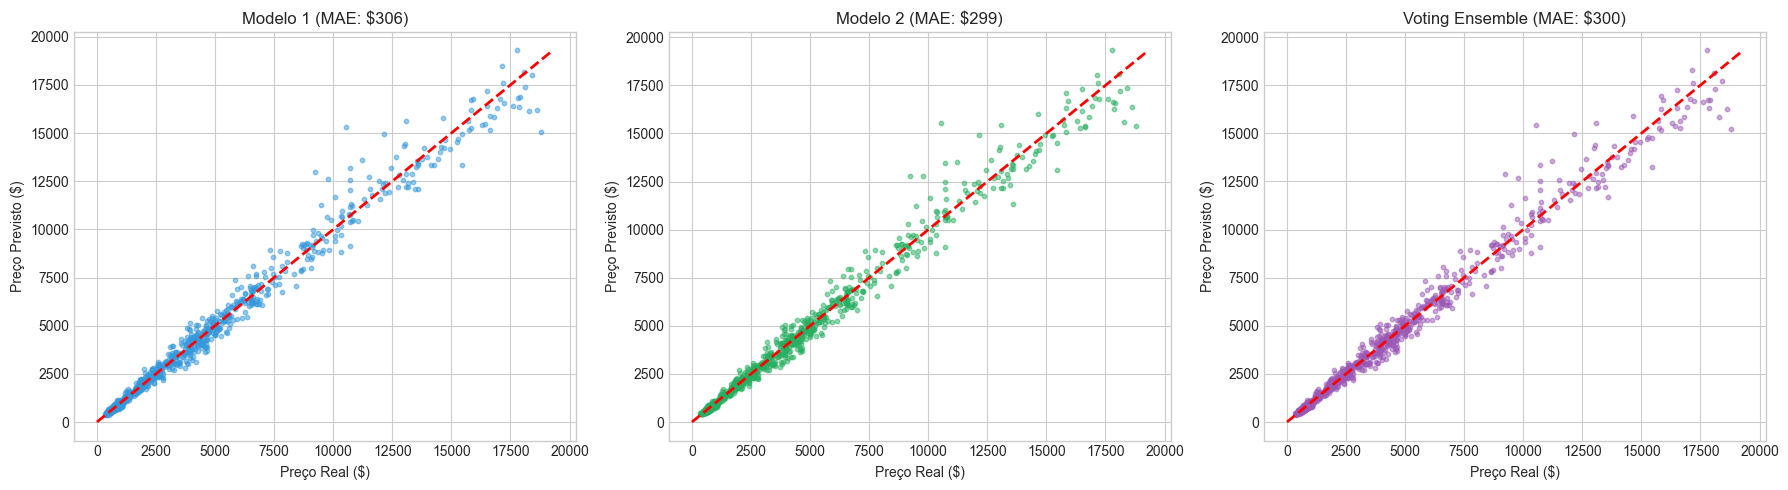

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample_size = 1000
indices = np.random.choice(len(y_test), sample_size, replace=False)
y_sample = y_test.iloc[indices].values

max_val = max(y_sample.max(), pred1[indices].max())

axes[0].scatter(y_sample, pred1[indices], alpha=0.5, s=10, c='#3498db')
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[0].set_xlabel('Preço Real ($)')
axes[0].set_ylabel('Preço Previsto ($)')
axes[0].set_title(f'Modelo 1 (MAE: ${mae1:,.0f})')

axes[1].scatter(y_sample, pred2[indices], alpha=0.5, s=10, c='#27ae60')
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Preço Real ($)')
axes[1].set_ylabel('Preço Previsto ($)')
axes[1].set_title(f'Modelo 2 (MAE: ${mae2:,.0f})')

axes[2].scatter(y_sample, pred_voting[indices], alpha=0.5, s=10, c='#9b59b6')
axes[2].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[2].set_xlabel('Preço Real ($)')
axes[2].set_ylabel('Preço Previsto ($)')
axes[2].set_title(f'Voting Ensemble (MAE: ${mae_voting:,.0f})')

plt.tight_layout()
plt.show()

### Comparação de MAE

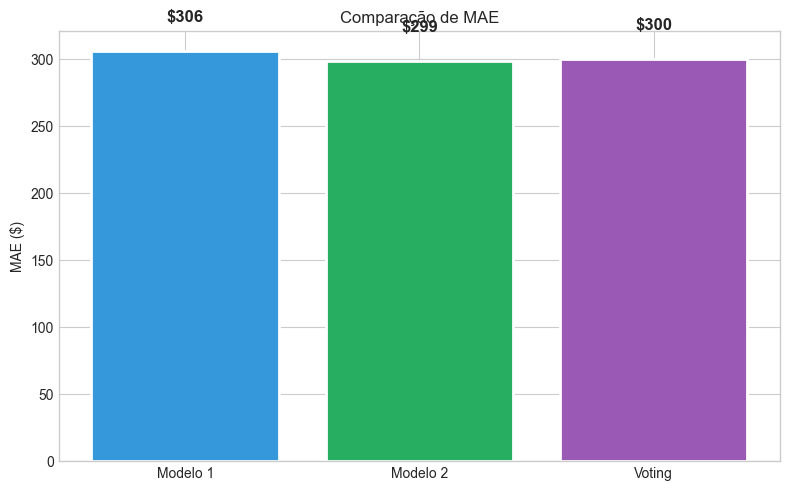

In [16]:
models_names = ['Modelo 1', 'Modelo 2', 'Voting']
maes = [mae1, mae2, mae_voting]
colors = ['#3498db', '#27ae60', '#9b59b6']

plt.figure(figsize=(8, 5))
bars = plt.bar(models_names, maes, color=colors, edgecolor='white', linewidth=2)
plt.ylabel('MAE ($)')
plt.title('Comparação de MAE')

for bar, mae in zip(bars, maes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'${mae:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Salvar Modelos

In [17]:
model1.save("model1.keras")
model2.save("model2.keras")
joblib.dump(preprocessor, "preprocessor.joblib")

import zipfile
with zipfile.ZipFile("models.zip", "w") as z:
    z.write("model1.keras")
    z.write("model2.keras")
    z.write("preprocessor.joblib")

from google.colab import files
files.download("models.zip")

ModuleNotFoundError: No module named 'google.colab'

## 7. Teste

In [ ]:
loaded_model1 = keras.models.load_model("model1.keras")
loaded_model2 = keras.models.load_model("model2.keras")
loaded_preprocessor = joblib.load("preprocessor.joblib")

test_diamond = pd.DataFrame([{
    'carat': 1.0,
    'cut': 'Ideal',
    'color': 'G',
    'clarity': 'VS1',
    'depth': 61.5,
    'table': 55.0,
    'x': 6.5,
    'y': 6.5,
    'z': 4.0
}])

test_processed = loaded_preprocessor.transform(test_diamond)
pred1_test = loaded_model1.predict(test_processed, verbose=0)[0][0]
pred2_test = loaded_model2.predict(test_processed, verbose=0)[0][0]
pred_voting_test = (pred1_test + pred2_test) / 2

pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2', 'Voting'],
    'Previsão ($)': [pred1_test, pred2_test, pred_voting_test]
})